In [29]:
#pip install pandas numpy matplotlib seaborn

In [30]:

#pip install --upgrade pip

In [31]:
pd.set_option('display.max_columns', None)

This project analyzes the relationship between Bitcoin market sentiment (Fear/Greed Index) and trader performance using historical trading data. The objective is to uncover patterns that can inform better trading strategies.

In [32]:
import pandas as pd

# Load datasets
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")


print(trades.head())
print(sentiment.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [33]:
# Clean column names
trades.columns = trades.columns.str.strip().str.lower().str.replace(" ", "_")
sentiment.columns = sentiment.columns.str.strip().str.lower().str.replace(" ", "_")

print(trades.columns)
print(sentiment.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='str')
Index(['timestamp', 'value', 'classification', 'date'], dtype='str')


In [34]:
# Convert trade timestamp to datetime
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], format='%d-%m-%Y %H:%M')

# Extract only date
trades['date'] = trades['timestamp_ist'].dt.date

# Convert sentiment date 
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date


print(trades[['timestamp_ist','date']].head())
print(sentiment[['date','classification']].head())

        timestamp_ist        date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02
         date classification
0  2018-02-01           Fear
1  2018-02-02   Extreme Fear
2  2018-02-03           Fear
3  2018-02-04   Extreme Fear
4  2018-02-05   Extreme Fear


In [35]:
print("Trades date range:", trades['date'].min(), "to", trades['date'].max())
print("Sentiment date range:", sentiment['date'].min(), "to", sentiment['date'].max())

Trades date range: 2023-05-01 to 2025-05-01
Sentiment date range: 2018-02-01 to 2025-05-02


In [36]:
merged = pd.merge(trades, sentiment, on='date', how='inner')

print(merged.head())
print("Shape:", merged.shape)

                                      account  coin  execution_price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   size_tokens  size_usd side       timestamp_ist  start_position direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   closed_pnl                                   transaction_hash     order_id  \
0         0

In [37]:
merged.groupby('classification')['closed_pnl'].mean()

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: closed_pnl, dtype: float64

Insight 1: Trader profitability varies significantly with market sentiment.

- Traders achieve the highest average profits during Extreme Greed phases.
- Surprisingly, Fear periods also show strong profitability.
- Neutral and Extreme Fear phases show comparatively lower profits.

This suggests that high market momentum (Extreme Greed) provides strong profit opportunities,
while Fear conditions may create undervalued entry points for skilled traders.

In [38]:
pd.crosstab(merged['side'], merged['classification'])

classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
side,,,,,
BUY,10935,17940,30270,24576,18969
SELL,10465,22052,31567,25727,18717


Insight 2: Trading activity remains balanced across market sentiments.

- Both BUY and SELL trades are consistently high across all sentiment categories.
- Slightly higher SELL activity is observed during Extreme Greed, suggesting profit booking behavior.
- Increased BUY activity during Fear phases may indicate traders attempting to buy undervalued assets.

This suggests that traders adapt their strategies based on sentiment, but overall market participation remains stable.

The relatively balanced trading behavior indicates that traders are active in both bullish and bearish conditions, rather than avoiding the market during uncertainty.

In [39]:
merged.groupby('classification')['size_usd'].mean()

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: size_usd, dtype: float64

Insight 3: Traders take higher risks during Fear phases rather than Greed.

- The average trade size is highest during Fear periods.
- Trade size decreases significantly during Extreme Greed.
- This suggests traders deploy more capital when the market is fearful.

This behavior indicates a contrarian strategy, where traders attempt to capitalize on undervalued assets during market downturns rather than chasing rising prices.

This contradicts the common assumption that traders are more aggressive during bullish markets, highlighting the presence of strategic, opportunity-driven trading behavior.

In [40]:
top_traders = merged.groupby('account')['closed_pnl'].sum().sort_values(ascending=False).head(10)

print(top_traders)

account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.605395e+05
Name: closed_pnl, dtype: float64


Insight 4: A small group of traders contributes disproportionately to overall profits.

- The top traders have achieved significantly high cumulative profits, with the highest exceeding 2 million.
- This indicates that trading success is highly concentrated among a few skilled participants.
- It suggests the presence of advanced strategies, better risk management, or superior market timing among top performers.

This highlights that consistent profitability in trading is not uniform across participants and may depend heavily on expertise and strategy.

In [41]:
merged.groupby('classification')['closed_pnl'].std()

classification
Extreme Fear     1136.056091
Extreme Greed     766.828294
Fear              935.355438
Greed            1116.028390
Neutral           517.122220
Name: closed_pnl, dtype: float64

Insight 5: Profit distribution varies widely across all sentiment categories.

All sentiment categories show a wide spread of profits and losses.
Extreme values (both high profits and heavy losses) are present in all conditions.
This indicates that while sentiment influences average profitability, individual trade outcomes remain highly volatile.

This suggests that market sentiment alone is not sufficient to guarantee success and must be combined with strong risk management.

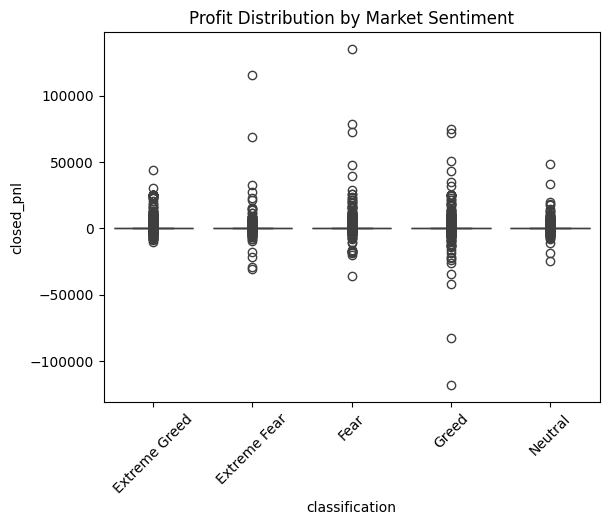

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='closed_pnl', data=merged)
plt.title("Profit Distribution by Market Sentiment")
plt.xticks(rotation=45)
plt.show()

Insight 6: Trading outcomes are highly volatile across all market conditions.

The standard deviation of profits is high across all sentiment categories.
This indicates that both gains and losses can be significant regardless of sentiment.

This highlights the importance of strong risk management strategies in trading.

Final Insights & Strategy Recommendations:

Market Sentiment Matters: Trader profitability is highest during Extreme Greed phases, indicating strong momentum-driven opportunities. However, Fear periods also offer profitable conditions, possibly due to undervalued assets.

Contrarian Trading Strategy: Higher trade sizes during Fear suggest that traders invest more when markets are down. This supports a contrarian approach — buying during Fear and capitalizing during recovery.

Balanced Market Participation: Trading activity (BUY vs SELL) remains consistent across all sentiment types, indicating that traders do not avoid the market but adapt their strategies based on conditions.

Risk Management Behavior: Lower trade sizes during Extreme Greed suggest cautious behavior despite higher profits, possibly to avoid sudden reversals.

Performance Inequality: A small group of traders dominates overall profits, indicating that skill, timing, and strategy significantly impact success.

Conclusion: An optimal trading strategy based on this analysis would involve:

Increasing exposure during Fear phases (value buying)
Leveraging momentum during Extreme Greed with controlled risk
Maintaining balanced participation rather than timing the market completely

These findings highlight that successful trading strategies depend on a combination of market awareness, risk management, and adaptive decision-making rather than relying solely on market sentiment.

In [45]:
#!jupyter nbconvert --to html Bitcoin.ipynb

[NbConvertApp] Converting notebook Bitcoin.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 350147 bytes to Bitcoin.html
